In [2]:
# %%
import pandas as pd

# ============================================
# STEP 1: LOAD ALL RAW DATASETS
# ============================================
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

print("Raw shapes:")
print(f"orders: {orders.shape}, order_items: {order_items.shape}, "
      f"products: {products.shape}, customers: {customers.shape}, "
      f"payments: {payments.shape}")

# %%
# ============================================
# STEP 2: FILTER DELIVERED ORDERS ONLY
# ============================================
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {orders_delivered.shape[0]} (out of {orders.shape[0]} total)")

# Convert ALL relevant date columns (not just 2 — added estimated/approved dates)
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders_delivered[col] = pd.to_datetime(orders_delivered[col])

# Sanity check: delivered orders should have a delivery date — flag if not
missing_delivery_date = orders_delivered['order_delivered_customer_date'].isnull().sum()
print(f"Delivered orders missing delivery date (data inconsistency): {missing_delivery_date}")

# %%
# ============================================
# STEP 3: CLEAN PRODUCTS
# ============================================
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# %%
# ============================================
# STEP 4: AGGREGATE PAYMENTS TO ORDER_ID LEVEL (one consistent method, no duplication)
# ============================================
payments_agg = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')   # consistent, no crash risk (mode() can fail on empty groups)
)
print(f"Payments aggregated: {payments_agg.shape[0]} unique orders "
      f"(raw payments rows: {payments.shape[0]})")

# %%
# ============================================
# STEP 5: MERGE INTO MASTER TABLE
# ============================================
master = orders_delivered.merge(order_items, on='order_id', how='inner')
master = master.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
master = master.merge(customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
master = master.merge(payments_agg, on='order_id', how='left')

print("Master table shape:", master.shape)
print("Columns:", master.columns.tolist())

# Note: multiple rows per order_id is EXPECTED here (one row per item in the order)
# Don't treat this as a "duplicate bug" — it's correct for item-level revenue analysis

# %%
# ============================================
# STEP 6: CHECK NULLS — BEFORE deciding action
# ============================================
null_report = master[['product_category_name', 'customer_state', 'payment_type',
                       'price', 'freight_value']].isnull().sum()
print("NULL counts in master table:")
print(null_report)
print(f"\nTotal rows: {master.shape[0]}")
print(f"% NULL customer_state: {master['customer_state'].isnull().mean()*100:.3f}%")
print(f"% NULL payment_type: {master['payment_type'].isnull().mean()*100:.3f}%")

# %%
# ============================================
# STEP 7: APPLY NULL HANDLING DECISIONS
# ============================================
before = master.shape[0]

# customer_state missing = broken customer match -> drop (should be tiny %)
master = master.dropna(subset=['customer_state'])

# payment_type missing = sale still happened, just unknown payment method -> fill
master['payment_type'] = master['payment_type'].fillna('unknown')

after = master.shape[0]
print(f"Dropped {before - after} rows due to missing customer_state ({(before-after)/before*100:.3f}%)")

# %%
# ============================================
# STEP 8: OUTLIER CHECK (flag only, don't remove yet)
# ============================================
print("price describe:")
print(master['price'].describe())

zero_or_negative_price = master[master['price'] <= 0].shape[0]
print(f"\nRows with price <= 0: {zero_or_negative_price}")

print("\nfreight_value describe:")
print(master['freight_value'].describe())

zero_freight = master[master['freight_value'] <= 0].shape[0]
print(f"Rows with freight_value <= 0: {zero_freight}")

# Top 1% price values — quick outlier glance
high_price_threshold = master['price'].quantile(0.99)
print(f"\n99th percentile price: {high_price_threshold:.2f}")
print(f"Rows above 99th percentile: {master[master['price'] > high_price_threshold].shape[0]}")

# %%
# ============================================
# STEP 9: FINAL SANITY CHECKS
# ============================================
print("Final master table shape:", master.shape)
print("\nNull check (should be 0 except maybe delivery dates):")
print(master.isnull().sum()[master.isnull().sum() > 0])

print("\nDistinct order_status (should only be 'delivered'):")
print(master['order_status'].unique())

print("\nDuplicate full-row check:")
print(f"Exact duplicate rows: {master.duplicated().sum()}")

Raw shapes:
orders: (99441, 8), order_items: (112650, 7), products: (32951, 9), customers: (99441, 5), payments: (103886, 5)
Delivered orders: 96478 (out of 99441 total)
Delivered orders missing delivery date (data inconsistency): 8
Payments aggregated: 99440 unique orders (raw payments rows: 103886)
Master table shape: (110197, 20)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_value', 'payment_type']
NULL counts in master table:
product_category_name    0
customer_state           0
payment_type             3
price                    0
freight_value            0
dtype: int64

Total rows: 110197
% NULL customer_state: 0.000%
% NULL payment_type: 0.003%
Dr

In [3]:
# %%
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/sales_pulse.db')

# Push CLEANED master table — replaces old sales_master
master.to_sql('sales_master', con=engine, if_exists='replace', index=False)

print("Cleaned data pushed to SQL successfully!")

# Sanity check
check = pd.read_sql("SELECT COUNT(*) as total_rows FROM sales_master", con=engine)
print(check)

Cleaned data pushed to SQL successfully!
   total_rows
0      110197


In [4]:
# %%
# Q1: Top 10 product categories by revenue
q1 = pd.read_sql("""
    SELECT product_category_name, 
           ROUND(SUM(price), 2) as total_revenue,
           COUNT(DISTINCT order_id) as total_orders
    FROM sales_master
    GROUP BY product_category_name
    ORDER BY total_revenue DESC
    LIMIT 10
""", con=engine)
print("TOP 10 CATEGORIES BY REVENUE:")
print(q1)

# Q2: Revenue by state
q2 = pd.read_sql("""
    SELECT customer_state,
           ROUND(SUM(price), 2) as total_revenue,
           COUNT(DISTINCT order_id) as total_orders
    FROM sales_master
    GROUP BY customer_state
    ORDER BY total_revenue DESC
    LIMIT 10
""", con=engine)
print("\n\nTOP 10 STATES BY REVENUE:")
print(q2)

TOP 10 CATEGORIES BY REVENUE:
    product_category_name  total_revenue  total_orders
0            beleza_saude     1233131.72          8647
1      relogios_presentes     1166176.98          5495
2         cama_mesa_banho     1023434.76          9272
3           esporte_lazer      954852.55          7530
4  informatica_acessorios      888724.61          6530
5        moveis_decoracao      711927.69          6307
6   utilidades_domesticas      615628.69          5743
7              cool_stuff      610204.10          3559
8              automotivo      578966.65          3810
9              brinquedos      471286.48          3804


TOP 10 STATES BY REVENUE:
  customer_state  total_revenue  total_orders
0             SP     5067633.16         40501
1             RJ     1759651.13         12350
2             MG     1552481.83         11354
3             RS      728897.47          5345
4             PR      666063.51          4923
5             SC      507012.13          3546
6             B

In [5]:
# %%
# Monthly data for forecasting (excluding incomplete last month)
monthly_data = pd.read_sql("""
    SELECT strftime('%Y-%m-01', order_purchase_timestamp) as ds,
           SUM(price) as y
    FROM sales_master
    WHERE order_purchase_timestamp >= '2017-01-01' 
      AND order_purchase_timestamp < '2018-09-01'
    GROUP BY ds
    ORDER BY ds
""", con=engine)

monthly_data['ds'] = pd.to_datetime(monthly_data['ds'])
print("Monthly data points:", monthly_data.shape)
print(monthly_data)

Monthly data points: (20, 2)
           ds          y
0  2017-01-01  111798.36
1  2017-02-01  234223.40
2  2017-03-01  359198.85
3  2017-04-01  340669.68
4  2017-05-01  489338.25
5  2017-06-01  421923.37
6  2017-07-01  481604.52
7  2017-08-01  554699.70
8  2017-09-01  607399.67
9  2017-10-01  648247.65
10 2017-11-01  987765.37
11 2017-12-01  726033.19
12 2018-01-01  924645.00
13 2018-02-01  826437.13
14 2018-03-01  953356.25
15 2018-04-01  973534.09
16 2018-05-01  977544.69
17 2018-06-01  856077.86
18 2018-07-01  867953.46
19 2018-08-01  838576.64


In [6]:
# %%
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

# Train/test split: first 17 months train, last 3 months test
train = monthly_data.iloc[:17]
test = monthly_data.iloc[17:]

model_test = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=False)
model_test.fit(train)

future_test = model_test.make_future_dataframe(periods=3, freq='MS')
forecast_test = model_test.predict(future_test)

result = test.merge(forecast_test[['ds','yhat']], on='ds')
print(result)

mape_real = mean_absolute_percentage_error(result['y'], result['yhat'])
print(f"\nREAL (out-of-sample) MAPE: {mape_real*100:.2f}%")

c:\Users\OM\anaconda3\envs\sales-pulse\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
01:13:21 - cmdstanpy - INFO - Chain [1] start processing
01:13:22 - cmdstanpy - INFO - Chain [1] done processing


          ds          y          yhat
0 2018-06-01  856077.86  1.107054e+06
1 2018-07-01  867953.46  1.159967e+06
2 2018-08-01  838576.64  1.214643e+06

REAL (out-of-sample) MAPE: 35.94%


In [7]:
# %%
# Try: changepoint_prior_scale adjust karke — model ko trend-shift ke liye zyada flexible banate hain
model_test2 = Prophet(
    weekly_seasonality=False, 
    daily_seasonality=False, 
    yearly_seasonality=False,
    changepoint_prior_scale=0.5  # default 0.05 hai — zyada flexible trend allow karta hai
)
model_test2.fit(train)

future_test2 = model_test2.make_future_dataframe(periods=3, freq='MS')
forecast_test2 = model_test2.predict(future_test2)

result2 = test.merge(forecast_test2[['ds','yhat']], on='ds')
print(result2)

mape_real2 = mean_absolute_percentage_error(result2['y'], result2['yhat'])
print(f"\nAdjusted MAPE (flexible trend): {mape_real2*100:.2f}%")

01:13:22 - cmdstanpy - INFO - Chain [1] start processing
01:13:22 - cmdstanpy - INFO - Chain [1] done processing


          ds          y          yhat
0 2018-06-01  856077.86  1.046144e+06
1 2018-07-01  867953.46  1.084804e+06
2 2018-08-01  838576.64  1.124754e+06

Adjusted MAPE (flexible trend): 27.10%


01:13:23 - cmdstanpy - INFO - Chain [1] start processing
01:13:41 - cmdstanpy - INFO - Chain [1] done processing


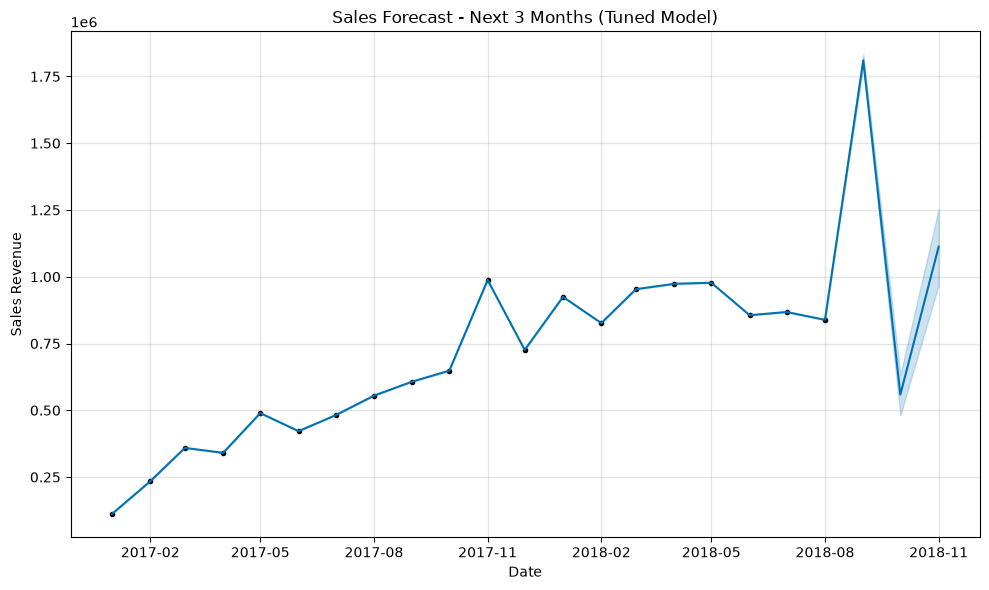

In [8]:
# %%
import matplotlib.pyplot as plt

# Final model - using full monthly_data (not just train) for the production forecast
model_final = Prophet(
    weekly_seasonality=False, 
    daily_seasonality=False, 
    yearly_seasonality=True,
    changepoint_prior_scale=0.5
)
model_final.fit(monthly_data)

future_final = model_final.make_future_dataframe(periods=3, freq='MS')
forecast_final = model_final.predict(future_final)

fig = model_final.plot(forecast_final)
plt.title("Sales Forecast - Next 3 Months (Tuned Model)")
plt.xlabel("Date")
plt.ylabel("Sales Revenue")
plt.tight_layout()
plt.savefig('../notebooks/forecast_plot.png')
plt.show()

01:13:42 - cmdstanpy - INFO - Chain [1] start processing
01:13:42 - cmdstanpy - INFO - Chain [1] done processing


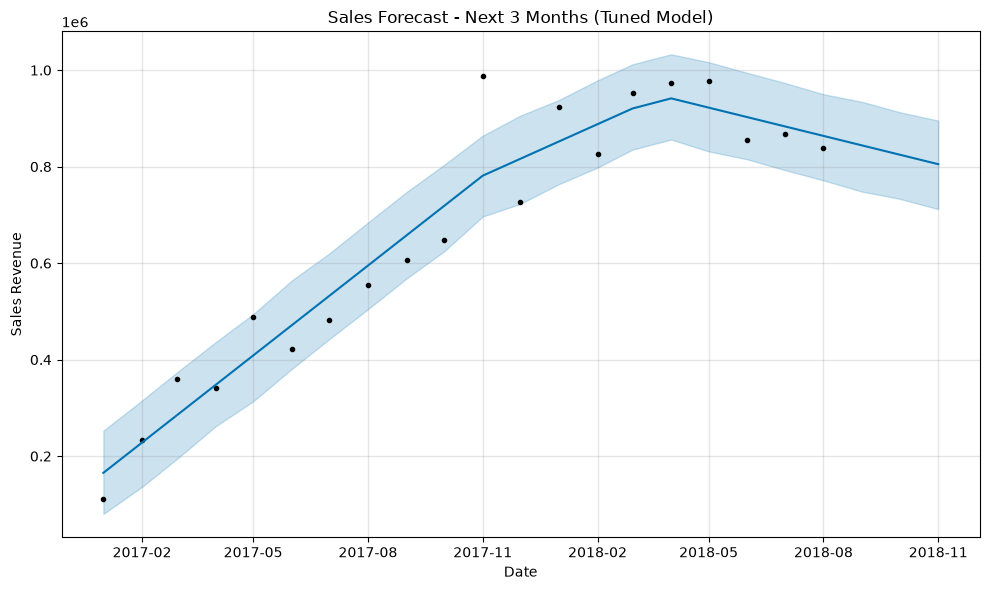

In [9]:
# %%
import matplotlib.pyplot as plt

# Final model — yearly_seasonality OFF (insufficient data for reliable yearly pattern)
model_final = Prophet(
    weekly_seasonality=False, 
    daily_seasonality=False, 
    yearly_seasonality=False,   # <-- changed from True
    changepoint_prior_scale=0.5
)
model_final.fit(monthly_data)

future_final = model_final.make_future_dataframe(periods=3, freq='MS')
forecast_final = model_final.predict(future_final)

fig = model_final.plot(forecast_final)
plt.title("Sales Forecast - Next 3 Months (Tuned Model)")
plt.xlabel("Date")
plt.ylabel("Sales Revenue")
plt.tight_layout()
plt.savefig('../notebooks/forecast_plot.png')
plt.show()

In [10]:
pd.read_sql("""
    SELECT order_id, COUNT(*) as cnt 
    FROM sales_master GROUP BY order_id ORDER BY cnt DESC LIMIT 10
""", engine)

,order_id,cnt
0,8272b63d03f5f79c56e9e4120aec44ef,21
1,ab14fdcfbe524636d65ee38360e22ce8,20
2,1b15974a0141d54e36626dca3fdc731a,20
3,9ef13efd6949e4573a18964dd1bbe7f5,15
4,428a2f660dc84138d969ccd69a0ab6d5,15
5,9bdc4d4c71aa1de4606060929dee888c,14
6,73c8ab38f07dc94389065f7eba4f297a,14
7,37ee401157a3a0b28c9c6d0ed8c3b24b,13
8,c05d6a79e55da72ca780ce90364abed9,12
9,af822dacd6f5cff7376413c03a388bb7,12


In [11]:
# %%
# Check: kya "Total Customers" actually unique persons hain, ya unique order-records?

# 1. Distinct customer_id check (jo abhi merge mein use ho raha hai)
check1 = pd.read_sql("""
    SELECT COUNT(*) FROM (
        SELECT customer_id FROM sales_master 
        GROUP BY customer_id HAVING COUNT(DISTINCT order_id) > 1
    )
""", engine)
print("Customers with >1 distinct order (using customer_id):")
print(check1)

# 2. Total distinct customer_id vs total distinct order_id
check2 = pd.read_sql("""
    SELECT 
        COUNT(DISTINCT customer_id) as unique_customer_ids,
        COUNT(DISTINCT order_id) as unique_order_ids
    FROM sales_master
""", engine)
print("\nUnique customer_id vs unique order_id:")
print(check2)

Customers with >1 distinct order (using customer_id):
   COUNT(*)
0         0

Unique customer_id vs unique order_id:
   unique_customer_ids  unique_order_ids
0                96478             96478


In [12]:
# %%
# Verify: ab genuine repeat customers dikhne chahiye customer_unique_id se
check3 = pd.read_sql("""
    SELECT 
        COUNT(DISTINCT customer_id) as unique_customer_ids,
        COUNT(DISTINCT customer_unique_id) as unique_persons,
        COUNT(DISTINCT order_id) as unique_orders
    FROM sales_master
""", engine)
print(check3)

# Genuine repeat customers
check4 = pd.read_sql("""
    SELECT COUNT(*) FROM (
        SELECT customer_unique_id FROM sales_master 
        GROUP BY customer_unique_id HAVING COUNT(DISTINCT order_id) > 1
    )
""", engine)
print("\nGenuine repeat customers (using customer_unique_id):")
print(check4)

   unique_customer_ids  unique_persons  unique_orders
0                96478           93358          96478

Genuine repeat customers (using customer_unique_id):
   COUNT(*)
0      2801


In [13]:
# %%
# Direct check: schema mein customer_unique_id hai ya nahi
schema_check = pd.read_sql("SELECT * FROM sales_master LIMIT 1", engine)
print(schema_check.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_value', 'payment_type']


In [14]:
# %%
# Schema check - kya customer_unique_id ab DB mein hai?
schema_check = pd.read_sql("SELECT * FROM sales_master LIMIT 1", engine)
print(schema_check.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_value', 'payment_type']


In [15]:
# %%
print(master.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_value', 'payment_type']


In [16]:
# %%
# Unique customer_id vs unique customer_unique_id vs unique order_id
check3 = pd.read_sql("""
    SELECT 
        COUNT(DISTINCT customer_id) as unique_customer_ids,
        COUNT(DISTINCT customer_unique_id) as unique_persons,
        COUNT(DISTINCT order_id) as unique_orders
    FROM sales_master
""", engine)
print(check3)

# %%
# Genuine repeat customers (real persons jinhone 2+ baar order kiya)
check4 = pd.read_sql("""
    SELECT COUNT(*) FROM (
        SELECT customer_unique_id FROM sales_master 
        GROUP BY customer_unique_id HAVING COUNT(DISTINCT order_id) > 1
    )
""", engine)
print("Genuine repeat customers:")
print(check4)

   unique_customer_ids  unique_persons  unique_orders
0                96478           93358          96478
Genuine repeat customers:
   COUNT(*)
0      2801


In [17]:
forecast_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
20,2018-09-01,843974.700775,748198.188152,934326.663177
21,2018-10-01,824852.573309,733390.144792,912870.471394
22,2018-11-01,805093.041595,711903.833944,895484.137851
